In [4]:
# Install pandas into the current Python environment (run this cell once), then import it
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
import pandas as pd
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "datasets"])
import matplotlib.pyplot as plt
from datasets import load_dataset
import sys, subprocess
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
from ast import literal_eval
df['job_skills']= df['job_skills'].apply(lambda x: literal_eval(x) if pd.notna(x) else x)


c:\Users\Admin\anaconda3\envs\python_data\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
job_titles = ['Data Analyst','Business Analyst','Data Engineer','Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles))&(df['job_country']=='United States')].copy()


C:\Users\Admin\AppData\Local\Temp\ipykernel_17188\3148579740.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


(0.0, 300000.0)

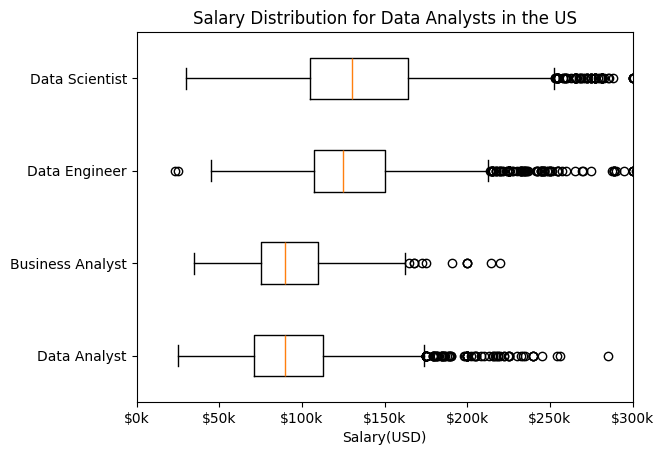

In [6]:

df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)

plt.title('Salary Distribution for Data Analysts in the US')
ax = plt.gca()
import matplotlib.ticker as mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k'))
plt.xlabel('Salary(USD)')
plt.xlim(0,300000)





Text(0, 0.5, ' ')

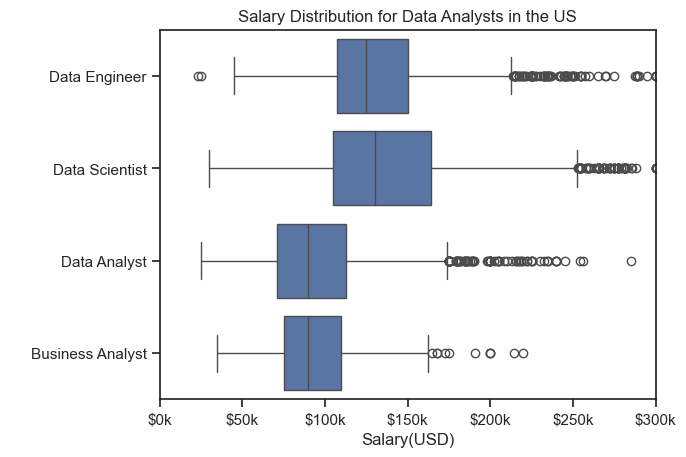

In [9]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
import seaborn as sns

sns.set_theme(style='ticks')
sns.boxplot(data=df_US, x='salary_year_avg',y='job_title_short')

plt.title('Salary Distribution for Data Analysts in the US')
ax = plt.gca()
import matplotlib.ticker as mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}k'))
plt.xlabel('Salary(USD)')
plt.xlim(0,300000)
plt.ylabel(' ')